In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#crim:犯罪率
#zn:大規模住宅地の割合
#indus:工業地帯の割合
#chas:チャールズ川沿いダミー変数(1は近い，0は近くない)
#nox:一酸化窒素濃度
#rm:平均部屋数
#age:古い住宅の割合
#dis:雇用センターへの距離
#rad:高速道路へのアクセス
#tax:固定資産税率
#ptratio:教員比率
#b:黒人割合の指数
#lstat:低所得者層の割合
#medv:住宅価格の中央値

data = pd.read_csv('./data/train.csv')

y = data["SalePrice"]
X = data.drop(columns="SalePrice")
data.isnull().sum()
# data.describe()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
print(data.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [19]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

model = lgb.LGBMRegressor(random_state=42)

model.fit(train_X, train_y)
pred = model.predict(test_X)

print(f"MAE : {mean_absolute_error(test_y, pred):.5f}")
print(f"R2S : {r2_score(test_y, pred):.5f}")


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: MSZoning: object, Street: object, Alley: object, LotShape: object, LandContour: object, Utilities: object, LotConfig: object, LandSlope: object, Neighborhood: object, Condition1: object, Condition2: object, BldgType: object, HouseStyle: object, RoofStyle: object, RoofMatl: object, Exterior1st: object, Exterior2nd: object, MasVnrType: object, ExterQual: object, ExterCond: object, Foundation: object, BsmtQual: object, BsmtCond: object, BsmtExposure: object, BsmtFinType1: object, BsmtFinType2: object, Heating: object, HeatingQC: object, CentralAir: object, Electrical: object, KitchenQual: object, Functional: object, FireplaceQu: object, GarageType: object, GarageFinish: object, GarageQual: object, GarageCond: object, PavedDrive: object, PoolQC: object, Fence: object, MiscFeature: object, SaleType: object, SaleCondition: object

In [2]:
data.corr(numeric_only=True)['SalePrice']

Id              -0.021917
MSSubClass      -0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond     -0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2      -0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF    -0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath    -0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch   -0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal         -0.021190
MoSold           0.046432
YrSold          -0.028923
SalePrice        1.000000
Name: SalePr

In [3]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

data = pd.concat([train, test])
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000806 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4074
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 81
[LightGBM] [Info] Start training from score 180521.299658
--- LightGBM ---
MAE : 16793.35496
R2S : 0.88258

--- XGBoost ---
MAE : 17432.74125
R2S : 0.86037

--- CatBost ---
MAE : 17720.93707
R2S : 0.84574

--- Ensemble ---
MAE : 16616.54520
R2S : 0.87338


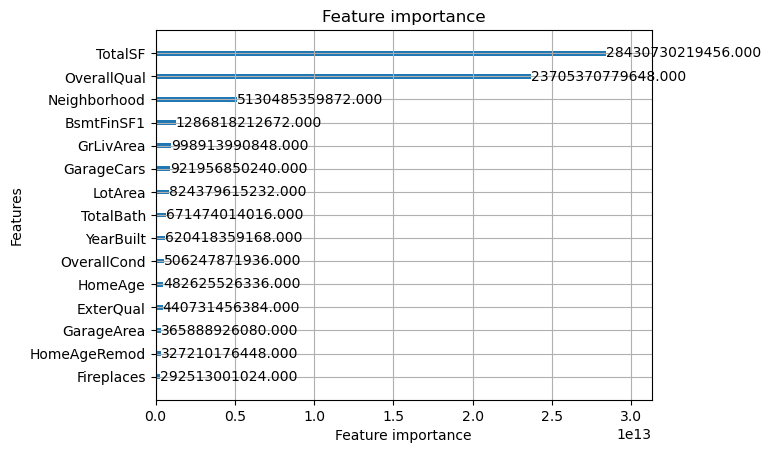

In [ ]:
import lightgbm as lgb
import catboost as cbst
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# data = pd.read_csv('./data/train.csv')
# test = pd.read_csv('./data/test.csv')

y = data["SalePrice"]
X = data.drop(columns="SalePrice")

columns = []
categorical = []
for column in X.columns.to_list():
    if X[column].dtype in ['int64', 'float64']:
        columns.append(column)
    elif X[column].dtype == 'object':
        X[column] = X[column].astype('category')
        test[column] = test[column].astype('category')
        categorical.append(column)

train_X_numeric = X[columns]

X['TotalBath'] = X['FullBath'] + 0.5 * X['HalfBath'] + X['BsmtFullBath']
X['HasPool'] = (X['PoolArea'] > 0).astype('int64')
X['TotalSF'] = X['1stFlrSF'] + X['2ndFlrSF'] + X['TotalBsmtSF']
X['HomeAge'] = X['YrSold'] - X['YearBuilt']
X['HomeAgeRemod'] = X['YrSold'] - X['YearRemodAdd']
X['GarageRatio'] = X['GarageArea'] / X['GrLivArea']
X.drop(columns='Id', inplace=True)

drop_columns = []
for column in train_X_numeric.columns.to_list():
    # if X[column].isnull().sum() < 50:
    #     drop_columns.append(column)
    # else :
    if np.abs(np.corrcoef(x=X[column], y=data['SalePrice']).all()) < 0.3:
        drop_columns.append(column)

X.drop(columns=drop_columns, inplace=True)
test.drop(columns=drop_columns, inplace=True)



train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

model1 = lgb.LGBMRegressor(random_state=42, num_leaves=20, learning_rate=0.05)
model2 = xgb.XGBRegressor(random_state=42, max_depth=4, learning_rate=0.05, n_estimators=100, enable_categorical=True)
model3 = cbst.CatBoostRegressor(random_state=42, learning_rate=0.05, max_depth=4, cat_features=categorical)

model1.fit(train_X, train_y, categorical_feature=categorical)
model2.fit(train_X, train_y)

pred1 = model1.predict(test_X)
pred2 = model2.predict(test_X)


lgb.plot_importance(model1, importance_type='gain', max_num_features=15)

for categ_column in categorical:
    if train_X[categ_column].isnull().sum() > 0:
        train_X[categ_column] = train_X[categ_column].cat.add_categories('Unknown')
        train_X[categ_column] = train_X[categ_column].fillna('Unknown')
        
    
    if test_X[categ_column].isnull().sum() > 0:
        test_X[categ_column] = test_X[categ_column].cat.add_categories('Unknown')
        test_X[categ_column] = test_X[categ_column].fillna('Unknown')

model3.fit(train_X, train_y, verbose=0)

pred3 = model3.predict(test_X)

print("--- LightGBM ---")
print(f'MAE : {mean_absolute_error(test_y, pred1):.5f}')
print(f'R2S : {r2_score(test_y, pred1):.5f}')
print()

print("--- XGBoost ---")
print(f'MAE : {mean_absolute_error(test_y, pred2):.5f}')
print(f'R2S : {r2_score(test_y, pred2):.5f}')
print()

print("--- CatBost ---")
print(f'MAE : {mean_absolute_error(test_y, pred3):.5f}')
print(f'R2S : {r2_score(test_y, pred3):.5f}')
print()

print("--- Ensemble ---")
ens_pred = (pred1 + pred2 + pred3) / 3.0
print(f'MAE : {mean_absolute_error(test_y, ens_pred):.5f}')
print(f'R2S : {r2_score(test_y, ens_pred):.5f}')

In [ ]:
pred_1 = model1.predict()

submission = pd.DataFrame

In [10]:
desc = data.describe()
desc.to_csv('./data/description.csv')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4375
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 86
[LightGBM] [Info] Start training from score 12.030658
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4362
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 86
[LightGBM] [Info] Start training from score 12.016898
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000751 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4353
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 85
[LightGBM] [Info] Start trai

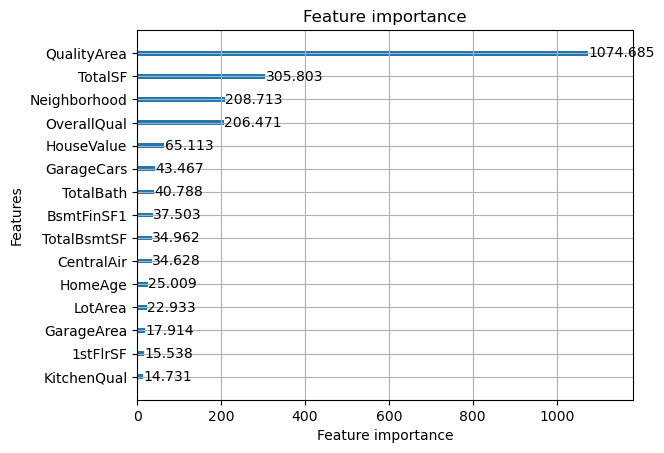

In [13]:
import lightgbm as lgb
import catboost as cbst
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, r2_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# data = pd.read_csv('./data/train.csv')
# test = pd.read_csv('./data/test.csv')

train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

data = pd.concat([train, test])

y = np.log1p(data.loc[:len(train)-1, "SalePrice"])
X = data.drop(columns="SalePrice", inplace=True)

data['TotalBath'] = data['FullBath'] + 0.5 * data['HalfBath'] + data['BsmtFullBath'] + 0.5 * data['BsmtHalfBath']
data['HasPool'] = (data['PoolArea'] > 0).astype('int64')
data['TotalSF'] = data['1stFlrSF'] + data['2ndFlrSF'] + data['TotalBsmtSF']
data['HomeAge'] = data['YrSold'] - data['YearBuilt']
data['HomeAgeRemod'] = data['YrSold'] - data['YearRemodAdd']
data['GarageRatio'] = data['GarageArea'] / data['GrLivArea']
data['HasCar'] = (data['GarageCars'] > 0).astype('int64')
data['HasFirePlace'] = (data['Fireplaces'] > 0).astype('int64')
data['QualityArea'] = data['OverallQual'] * data['GrLivArea']
data['HouseValue'] = data['OverallQual'] * data['OverallCond']
# X.drop(columns='Id', inplace=True)

numeric_columns = []
categorical = []
for column in data.columns.to_list():
    if data[column].dtype in ['int64', 'float64']:
        numeric_columns.append(column)
    elif data[column].dtype == 'object':
        data[column] = data[column].astype('category')
        categorical.append(column)

drop_columns = []
# for column in train_X_numeric.columns.to_list():
#     # data[:len(train)]['SalePrice']
#     if np.abs(np.corrcoef(x=data.loc[:len(train)-1, column], y=y).all()) < 0.3:
#         drop_columns.append(column)

data.drop(columns=drop_columns, inplace=True)

train_X, test_X = data.iloc[:len(train)].copy(), data.iloc[len(train):].copy()
# test_X.drop(columns='SalePrice', inplace=True)

# train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

model1 = lgb.LGBMRegressor(random_state=42, num_leaves=20, learning_rate=0.05)
model2 = xgb.XGBRegressor(random_state=42, max_depth=4, learning_rate=0.05, n_estimators=100, enable_categorical=True)
model3 = cbst.CatBoostRegressor(random_state=42, learning_rate=0.05, max_depth=4, cat_features=categorical)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores1 = cross_validate(model1, train_X, y, cv=kf, return_train_score=True)
scores2 = cross_validate(model2, train_X, y, cv=kf, return_train_score=True)

# print(f'model1 : {-scores1.mean()}')
# print(f'model2 : {-scores2.mean()}')
scores1 = []
scores2 = []

for train_idx, valid_idx in kf.split(train_X):

    X_tr = train_X.iloc[train_idx]
    X_va = train_X.iloc[valid_idx]

    y_tr = y.iloc[train_idx]
    y_va = y.iloc[valid_idx]

    model1.fit(
        X_tr,
        y_tr,
    )

    model2.fit(
        X_tr,
        y_tr,
    )

    pred1 = model1.predict(X_va)
    pred2 = model2.predict(X_va)

    rmse1 = np.sqrt(
        np.mean((pred1 - y_va) ** 2)
    )

    rmse2 = np.sqrt(
        np.mean((pred2 - y_va) ** 2)
    )

    scores1.append(rmse1)
    scores2.append(rmse2)

print(np.mean(scores1))
print(np.mean(scores2))

model1.fit(train_X, y, categorical_feature=categorical)
model2.fit(train_X, y)

pred1 = model1.predict(test_X)
pred2 = model2.predict(test_X)

pred1 = np.expm1(pred1)
pred2 = np.expm1(pred2)

lgb.plot_importance(model1, importance_type='gain', max_num_features=15)

for categ_column in categorical:
    if train_X[categ_column].isnull().sum() > 0:
        train_X[categ_column] = train_X[categ_column].cat.add_categories('Unknown')
        train_X[categ_column] = train_X[categ_column].fillna('Unknown')
        
    if test_X[categ_column].isnull().sum() > 0:
        test_X[categ_column] = test_X[categ_column].cat.add_categories('Unknown')
        test_X[categ_column] = test_X[categ_column].fillna('Unknown')

for column in numeric_columns:
    if train_X[column].isnull().sum() > 0:
        train_X[column] = train_X[column].fillna(np.median(train_X[column]))
        test_X[column] = test_X[column].fillna(np.median(train_X[column]))

# scores3 = cross_validate(model3, train_X, y, cv=kf, return_train_score=True)
scores = []

for train_idx, valid_idx in kf.split(train_X):

    X_tr = train_X.iloc[train_idx]
    X_va = train_X.iloc[valid_idx]

    y_tr = y.iloc[train_idx]
    y_va = y.iloc[valid_idx]

    model = cbst.CatBoostRegressor(
        random_state=42,
        learning_rate=0.05,
        max_depth=4
    )

    model.fit(
        X_tr,
        y_tr,
        cat_features=categorical,
        verbose=0
    )

    pred = model.predict(X_va)

    rmse = np.sqrt(
        np.mean((pred - y_va) ** 2)
    )

    scores.append(rmse)

print(np.mean(scores))

model3.fit(train_X, y, verbose=0, cat_features=categorical)

pred3 = model3.predict(test_X)
pred3 = np.expm1(pred3)


In [11]:
desc = data.describe()
desc.to_csv('./data/description.csv')

desc['TotalBath'].describe()

count       8.000000
mean      366.750602
std      1030.458214
min         0.817124
25%         1.375000
50%         2.093846
75%         3.625000
max      2917.000000
Name: TotalBath, dtype: float64

In [14]:
import os 

SAVE_DIR = './submission'

ens_pred = 0.3 * pred1 + 0.2 * pred2 + 0.5 * pred3

submission = pd.DataFrame({
    'Id':test['Id'],
    'SalePrice':ens_pred
})

os.makedirs(SAVE_DIR, exist_ok=True)
submission.to_csv(f'{SAVE_DIR}/submission.csv', index=False)